In [1]:
import numpy as np

In [17]:
def get_chunk_indices(list_size, num_chunks):
    """
    Calculate the indices of the chunks for a list of a given size and number of chunks.

    Parameters:
    list_size (int): The size of the list to be chunked.
    num_chunks (int): The number of chunks to create.

    Returns:
    numpy array: The indices of the chunks.

    Example:
    chunked_list_indices(10, 3) -> array([0, 0, 0, 0, 1, 1, 1, 2, 2, 2])
    """
    chunk_sizes = np.full(num_chunks, list_size // num_chunks)
    chunk_sizes[:list_size % num_chunks] += 1
    chunk_indices = np.repeat(np.arange(num_chunks), chunk_sizes)
    return chunk_indices

def chunked_list(list, num_chunks):
    """"
    Get a list of chunks from a given list.
    """
    chunk_indices = get_chunk_indices(len(list), num_chunks)
    chunked_list = [list[chunk_indices == i] for i in np.unique(chunk_indices)]
    return chunk_indices, chunked_list

In [18]:
a, b = chunked_list(np.arange(10), 3)

In [19]:
a

array([0, 0, 0, 0, 1, 1, 1, 2, 2, 2])

In [20]:
b

[array([0, 1, 2, 3]), array([4, 5, 6]), array([7, 8, 9])]

In [3]:
# Test the chunk_data function
data_coords = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6], [0.7, 0.8]])
time_scale = 0.5
freq_scale = 0.5
print(chunk_data(data_coords, time_scale, freq_scale))

[0 0 2 2]


In [4]:
(data_coords[:, 0] / time_scale).astype(int)

array([0, 0, 1, 1])

Last samples after convergence: [[ 0.85425806 -1.77095045]
 [ 1.92621708 -0.26651897]
 [ 0.69758667 -0.22056688]
 [ 0.58875841  1.95286792]
 [ 1.8407061   0.56585884]
 [ 1.97369363 -0.86896031]
 [-0.25765272  0.39916916]
 [ 1.14539088 -0.3633013 ]
 [ 0.07203864  0.42840753]
 [ 0.23183072  0.40657446]
 [ 1.73738108 -0.14716183]
 [-0.13295266 -0.66148776]
 [ 0.96440745  1.48353421]
 [-0.96231877 -0.68002724]
 [ 1.2008399   0.50221668]
 [-0.36642672  0.76333538]
 [ 0.33729908  0.87340298]
 [ 0.39250138  0.34940549]
 [-0.48364701  0.84525828]
 [ 0.70736555  0.17658715]
 [ 0.78363112  0.49610095]
 [ 0.29157812 -2.09681358]
 [-1.51967103  1.68094349]
 [-0.50672965  0.67707452]
 [-0.57455885  0.43329026]
 [-0.64936335 -1.09108069]
 [-0.64612324  0.26448545]
 [ 0.2478737   0.38851308]
 [ 2.21551516 -0.24972712]
 [-0.49388258  0.21627121]
 [-2.25218282  1.05119052]
 [ 2.36352144 -1.14015241]
 [-1.89984823 -0.43091042]
 [ 0.10987676  0.46270157]
 [ 1.08993058 -1.12768331]
 [ 1.67183484 -2.360418

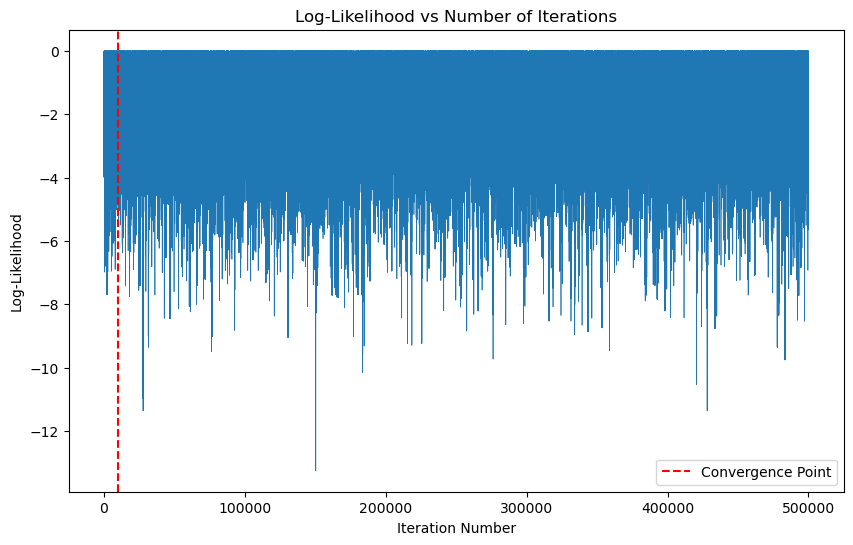

In [1]:
import emcee
import numpy as np
import matplotlib.pyplot as plt

# Define your log-probability function
def log_prob_fn(theta):
    # Example: A simple Gaussian log-likelihood (replace with your actual log-likelihood function)
    return -0.5 * np.sum(theta**2)

# Initial setup
ndim = 2  # Number of dimensions (parameters)
n_walkers = 50  # Number of walkers
n_initial_steps = 100  # Initial number of steps before evaluating convergence
initial_pos = np.random.randn(n_walkers, ndim)  # Initial positions of the walkers

# Initialize the sampler
sampler = emcee.EnsembleSampler(n_walkers, ndim, log_prob_fn)

# Define convergence criterion parameters
window = 50  # Rolling window size
threshold_std = 0.01  # Threshold for standard deviation to consider it as a plateau

# Run MCMC iteratively
current_pos = initial_pos
for iteration in range(1, 10000):  # Maximum number of iterations
    current_pos, log_prob, _ = sampler.run_mcmc(current_pos, 1, progress=False)  # Run one step

    # Get the log-likelihoods for all walkers at the current iteration
    log_likelihoods = sampler.get_log_prob(flat=True)  # Flatten to get all iterations for all walkers

    # Check if we have enough iterations to start evaluating convergence
    if iteration >= n_initial_steps:
        # Calculate rolling mean and standard deviation
        rolling_std = np.std(log_likelihoods[-window:])

        # Check if the standard deviation within the window is below the threshold
        if rolling_std < threshold_std:
            print(f"Convergence reached after {iteration} iterations.")
            break

# Retrieve the last samples after convergence
last_samples = sampler.get_chain(discard=0, thin=1, flat=True)[-n_walkers:]
print("Last samples after convergence:", last_samples)

# Plot the log-likelihood vs. number of iterations
plt.figure(figsize=(10, 6))
plt.plot(log_likelihoods, lw=0.5)
plt.xlabel('Iteration Number')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs Number of Iterations')
plt.axvline(x=iteration, color='red', linestyle='--', label='Convergence Point')
plt.legend()
plt.show()

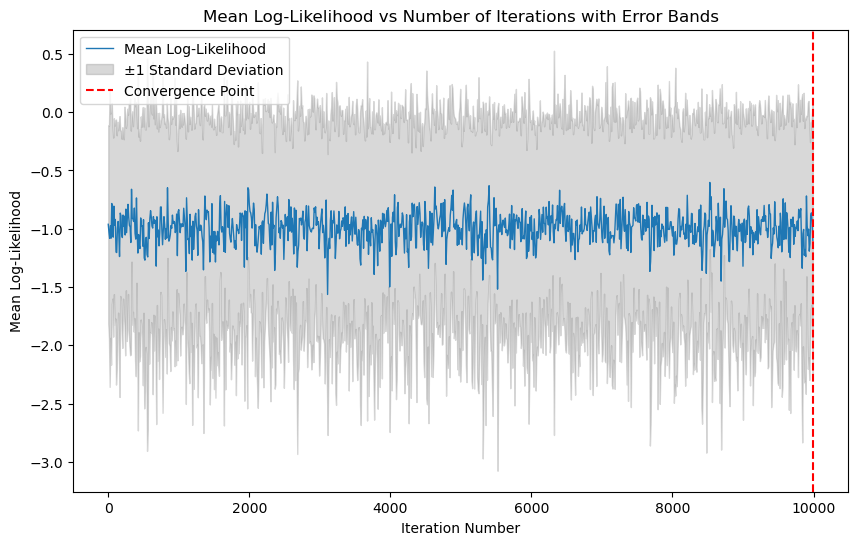

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Compute the mean and standard deviation of log-likelihoods across all walkers at each step
log_likelihoods = sampler.get_log_prob(discard=0, flat=False)  # Shape: (n_steps, n_walkers)

mean_log_likelihood = np.mean(log_likelihoods, axis=1)  # Mean across walkers for each step
std_log_likelihood = np.std(log_likelihoods, axis=1)    # Standard deviation across walkers for each step

# Thinning factor to reduce the number of points plotted (adjust as needed)
thin_factor = 10
thinned_iterations = np.arange(len(mean_log_likelihood))[::thin_factor]
thinned_mean_log_likelihood = mean_log_likelihood[::thin_factor]
thinned_std_log_likelihood = std_log_likelihood[::thin_factor]

# Plot the mean log-likelihood with error bands
plt.figure(figsize=(10, 6))
plt.plot(thinned_iterations, thinned_mean_log_likelihood, lw=1, label='Mean Log-Likelihood')
plt.fill_between(
    thinned_iterations,
    thinned_mean_log_likelihood - thinned_std_log_likelihood,
    thinned_mean_log_likelihood + thinned_std_log_likelihood,
    color='gray',
    alpha=0.3,
    label='±1 Standard Deviation'
)

plt.xlabel('Iteration Number')
plt.ylabel('Mean Log-Likelihood')
plt.title('Mean Log-Likelihood vs Number of Iterations with Error Bands')
plt.axvline(x=iteration, color='red', linestyle='--', label='Convergence Point')
plt.legend()
plt.show()